# Refactor: Whole Genome Deconvolution through 10 kb windows

**Background:** 
Analyses require examining specific nucleosome positions, transcription factor binding sites, and downstream gene body chromatin signatures. Additionally, we have shown that we are able to deconvolve a 3 kb window for 5500 genes (16 Mb). So it should be straightforward efficiency-wise to deconvolve the entire 12 Mb yeast genome in chunks. Potential challenge is how many bp can we deconvolve at once? 10 kb is the typical window in which we deconvolve...

**Procedure**
1. Deconvolve a 10 kb window, observe memory strain and potential output plots
2. Create a list of all 10 kb windows to deconvolve, revisit copy number correction csv.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from src.GenomeDeconvolution import GenomeDeconvolution

outdir = "output/deconvolved_genome_g0066_10k_10x10_2024_09_19"
genome_deconvolution = GenomeDeconvolution(save_dir=outdir)

In [22]:
genome_deconvolution.load_chrom_span(1, (0, 10010))

Already loaded chromosome reads for 1. Using cache.
Applying a normalization for length distribution
Applying chromatin copy number correction
Unflattened the input data is of shape: (16, 23, 910)
The size of our input data, G is: (16, 20930)
Already loaded chromosome reads for 1. Using cache.
Applying a normalization for length distribution
Applying chromatin copy number correction
Unflattened the input data is of shape: (15, 23, 910)
The size of our input data, G is: (15, 20930)


In [23]:
genome_deconvolution.combined_model.deconvolve()

Deconvolving combined model with gamma=0.006
Deconvolving bin size: 11x11
of G shape: (31, 20930)
Deconvolving with gamma=0.006
0/20930 - 00:00:00.131
500/20930 - 00:00:35.206
1000/20930 - 00:01:11.158
1500/20930 - 00:01:47.002
2000/20930 - 00:02:22.075
2500/20930 - 00:02:57.137
3000/20930 - 00:03:31.559
3500/20930 - 00:04:05.709
4000/20930 - 00:04:39.898
4500/20930 - 00:05:13.066
5000/20930 - 00:05:44.034
5500/20930 - 00:06:14.356
6000/20930 - 00:06:46.151
6500/20930 - 00:07:19.156
7000/20930 - 00:07:50.422
7500/20930 - 00:08:21.333
8000/20930 - 00:08:51.882
8500/20930 - 00:09:22.070
9000/20930 - 00:09:51.448
9500/20930 - 00:10:21.578
10000/20930 - 00:10:51.073
10500/20930 - 00:11:21.251
11000/20930 - 00:11:50.985
11500/20930 - 00:12:21.365
12000/20930 - 00:12:52.489
12500/20930 - 00:13:23.328
13000/20930 - 00:13:54.287
13500/20930 - 00:14:25.191
14000/20930 - 00:14:56.587
14500/20930 - 00:15:26.950
15000/20930 - 00:15:57.968
15500/20930 - 00:16:28.008
16000/20930 - 00:16:59.695
16500

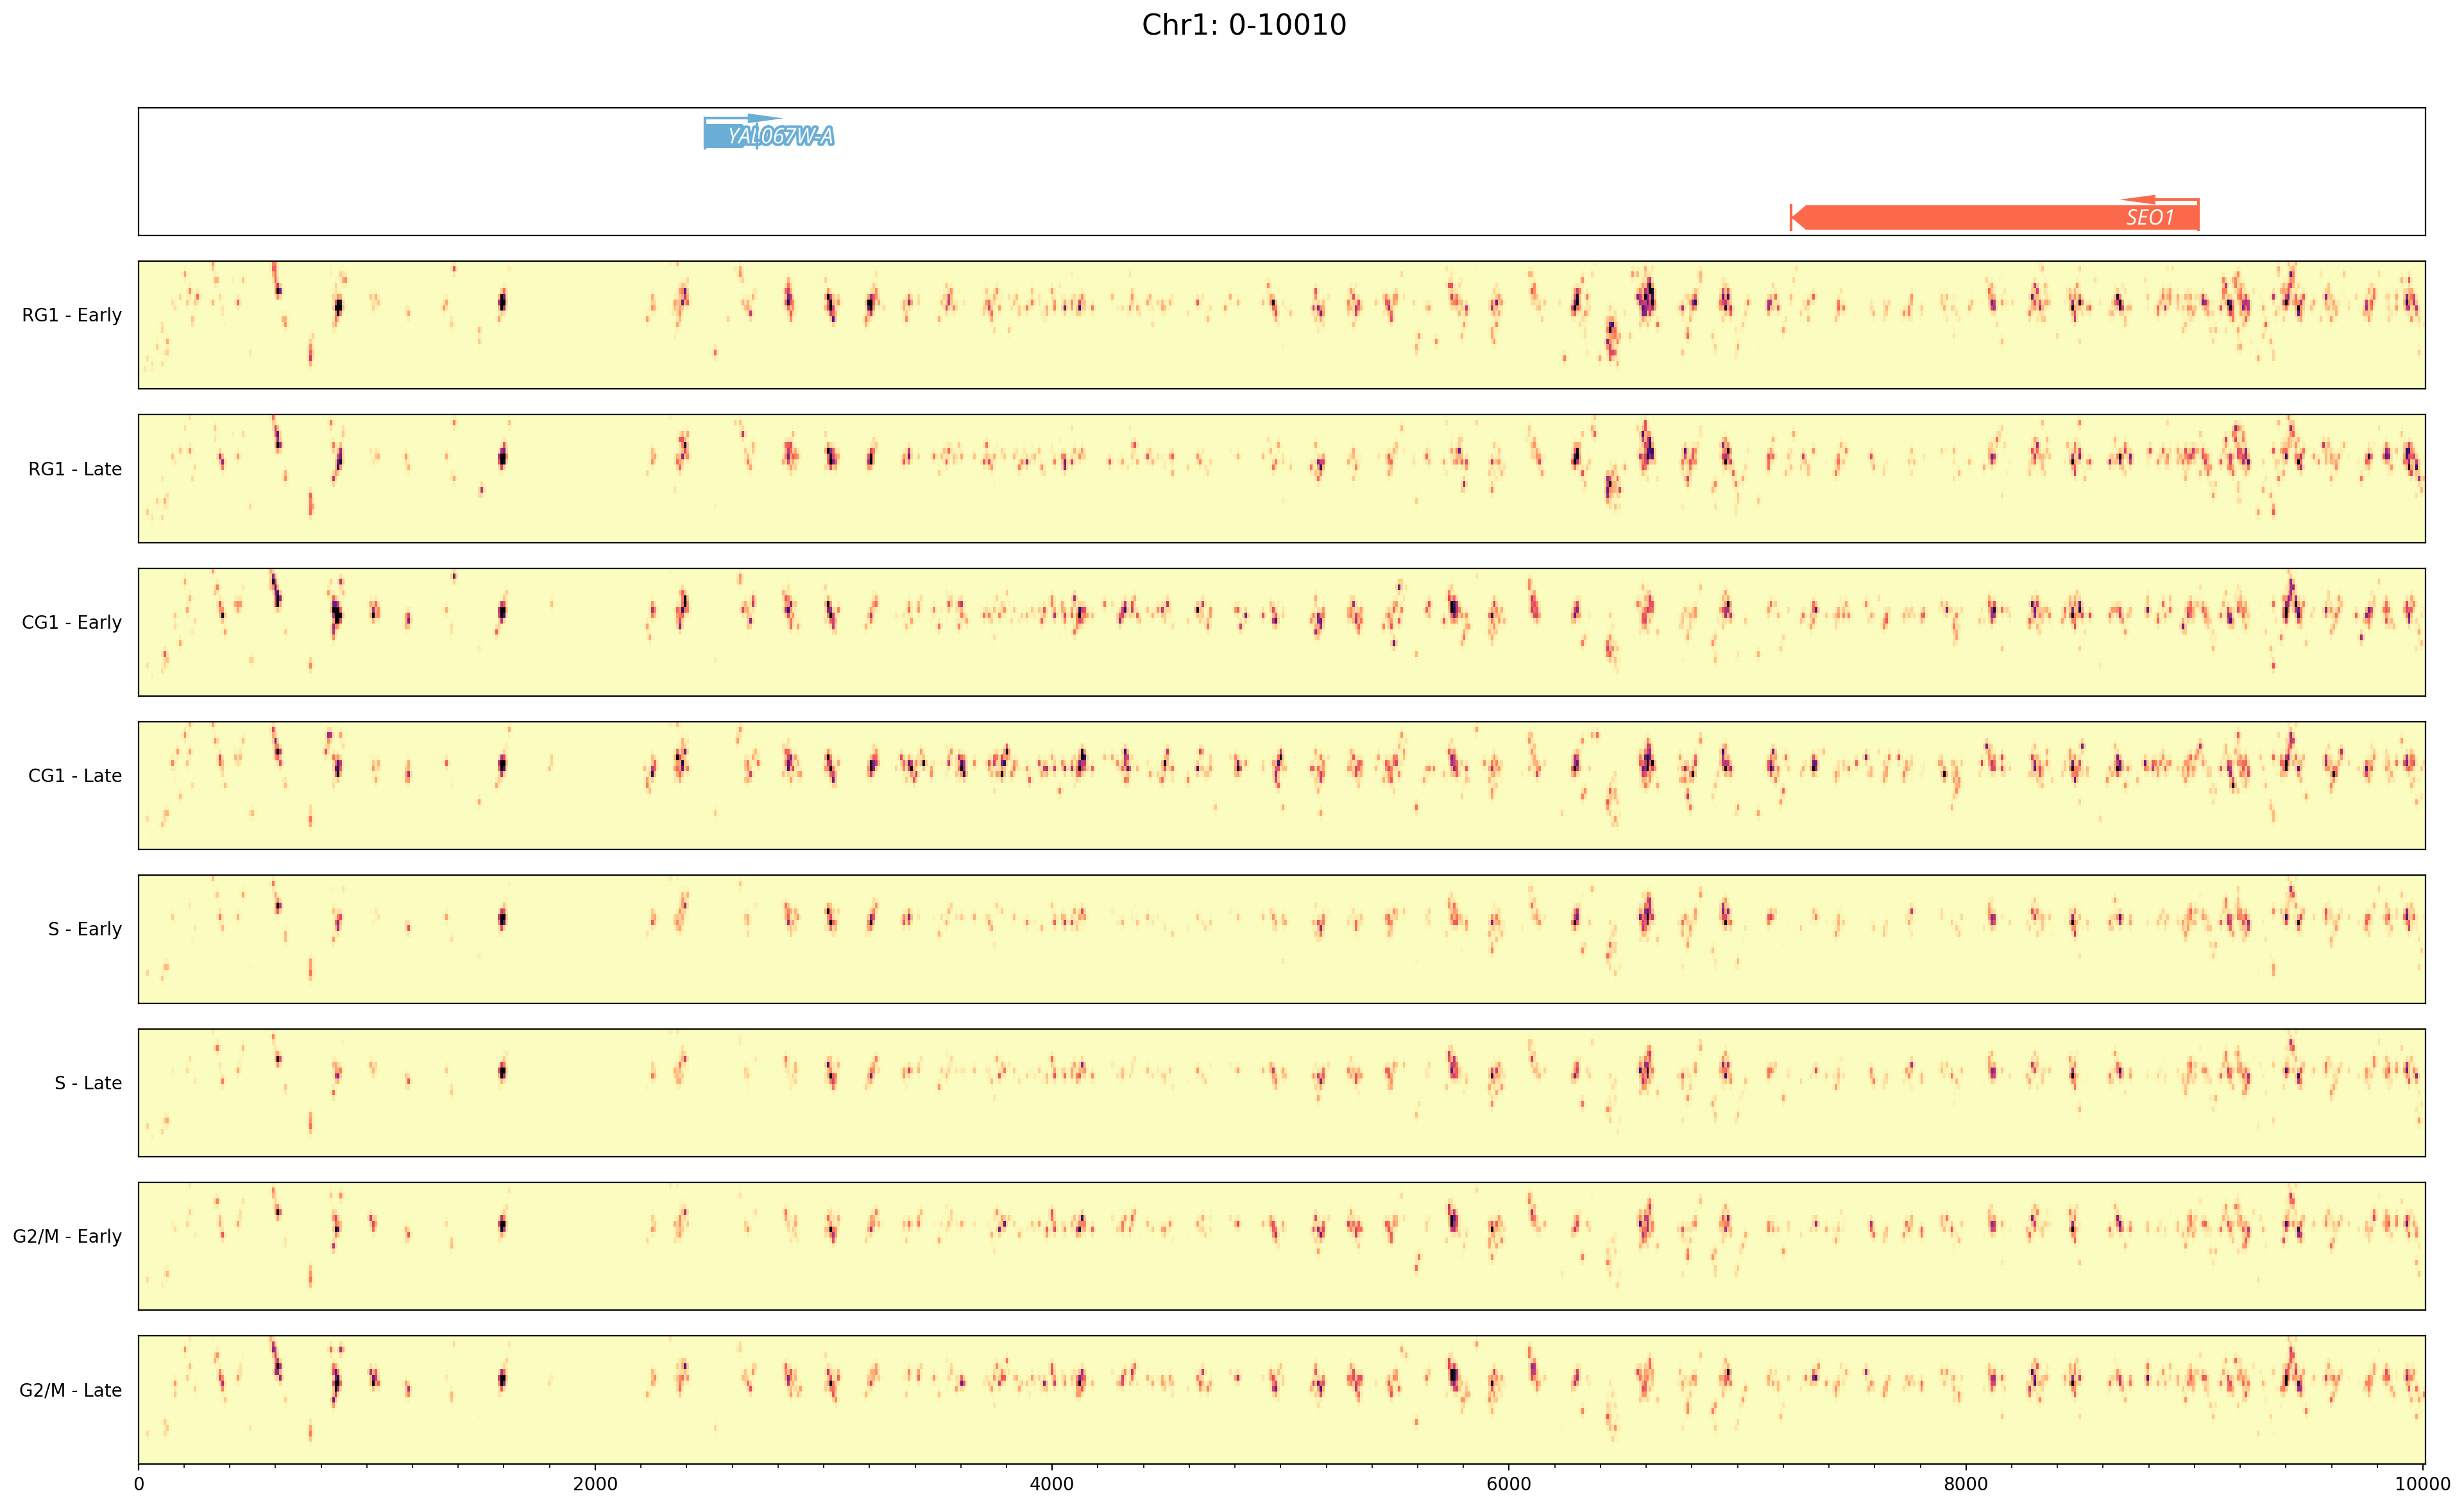

In [170]:
genome_deconvolution.plot_deconvolved_result(smooth=True)

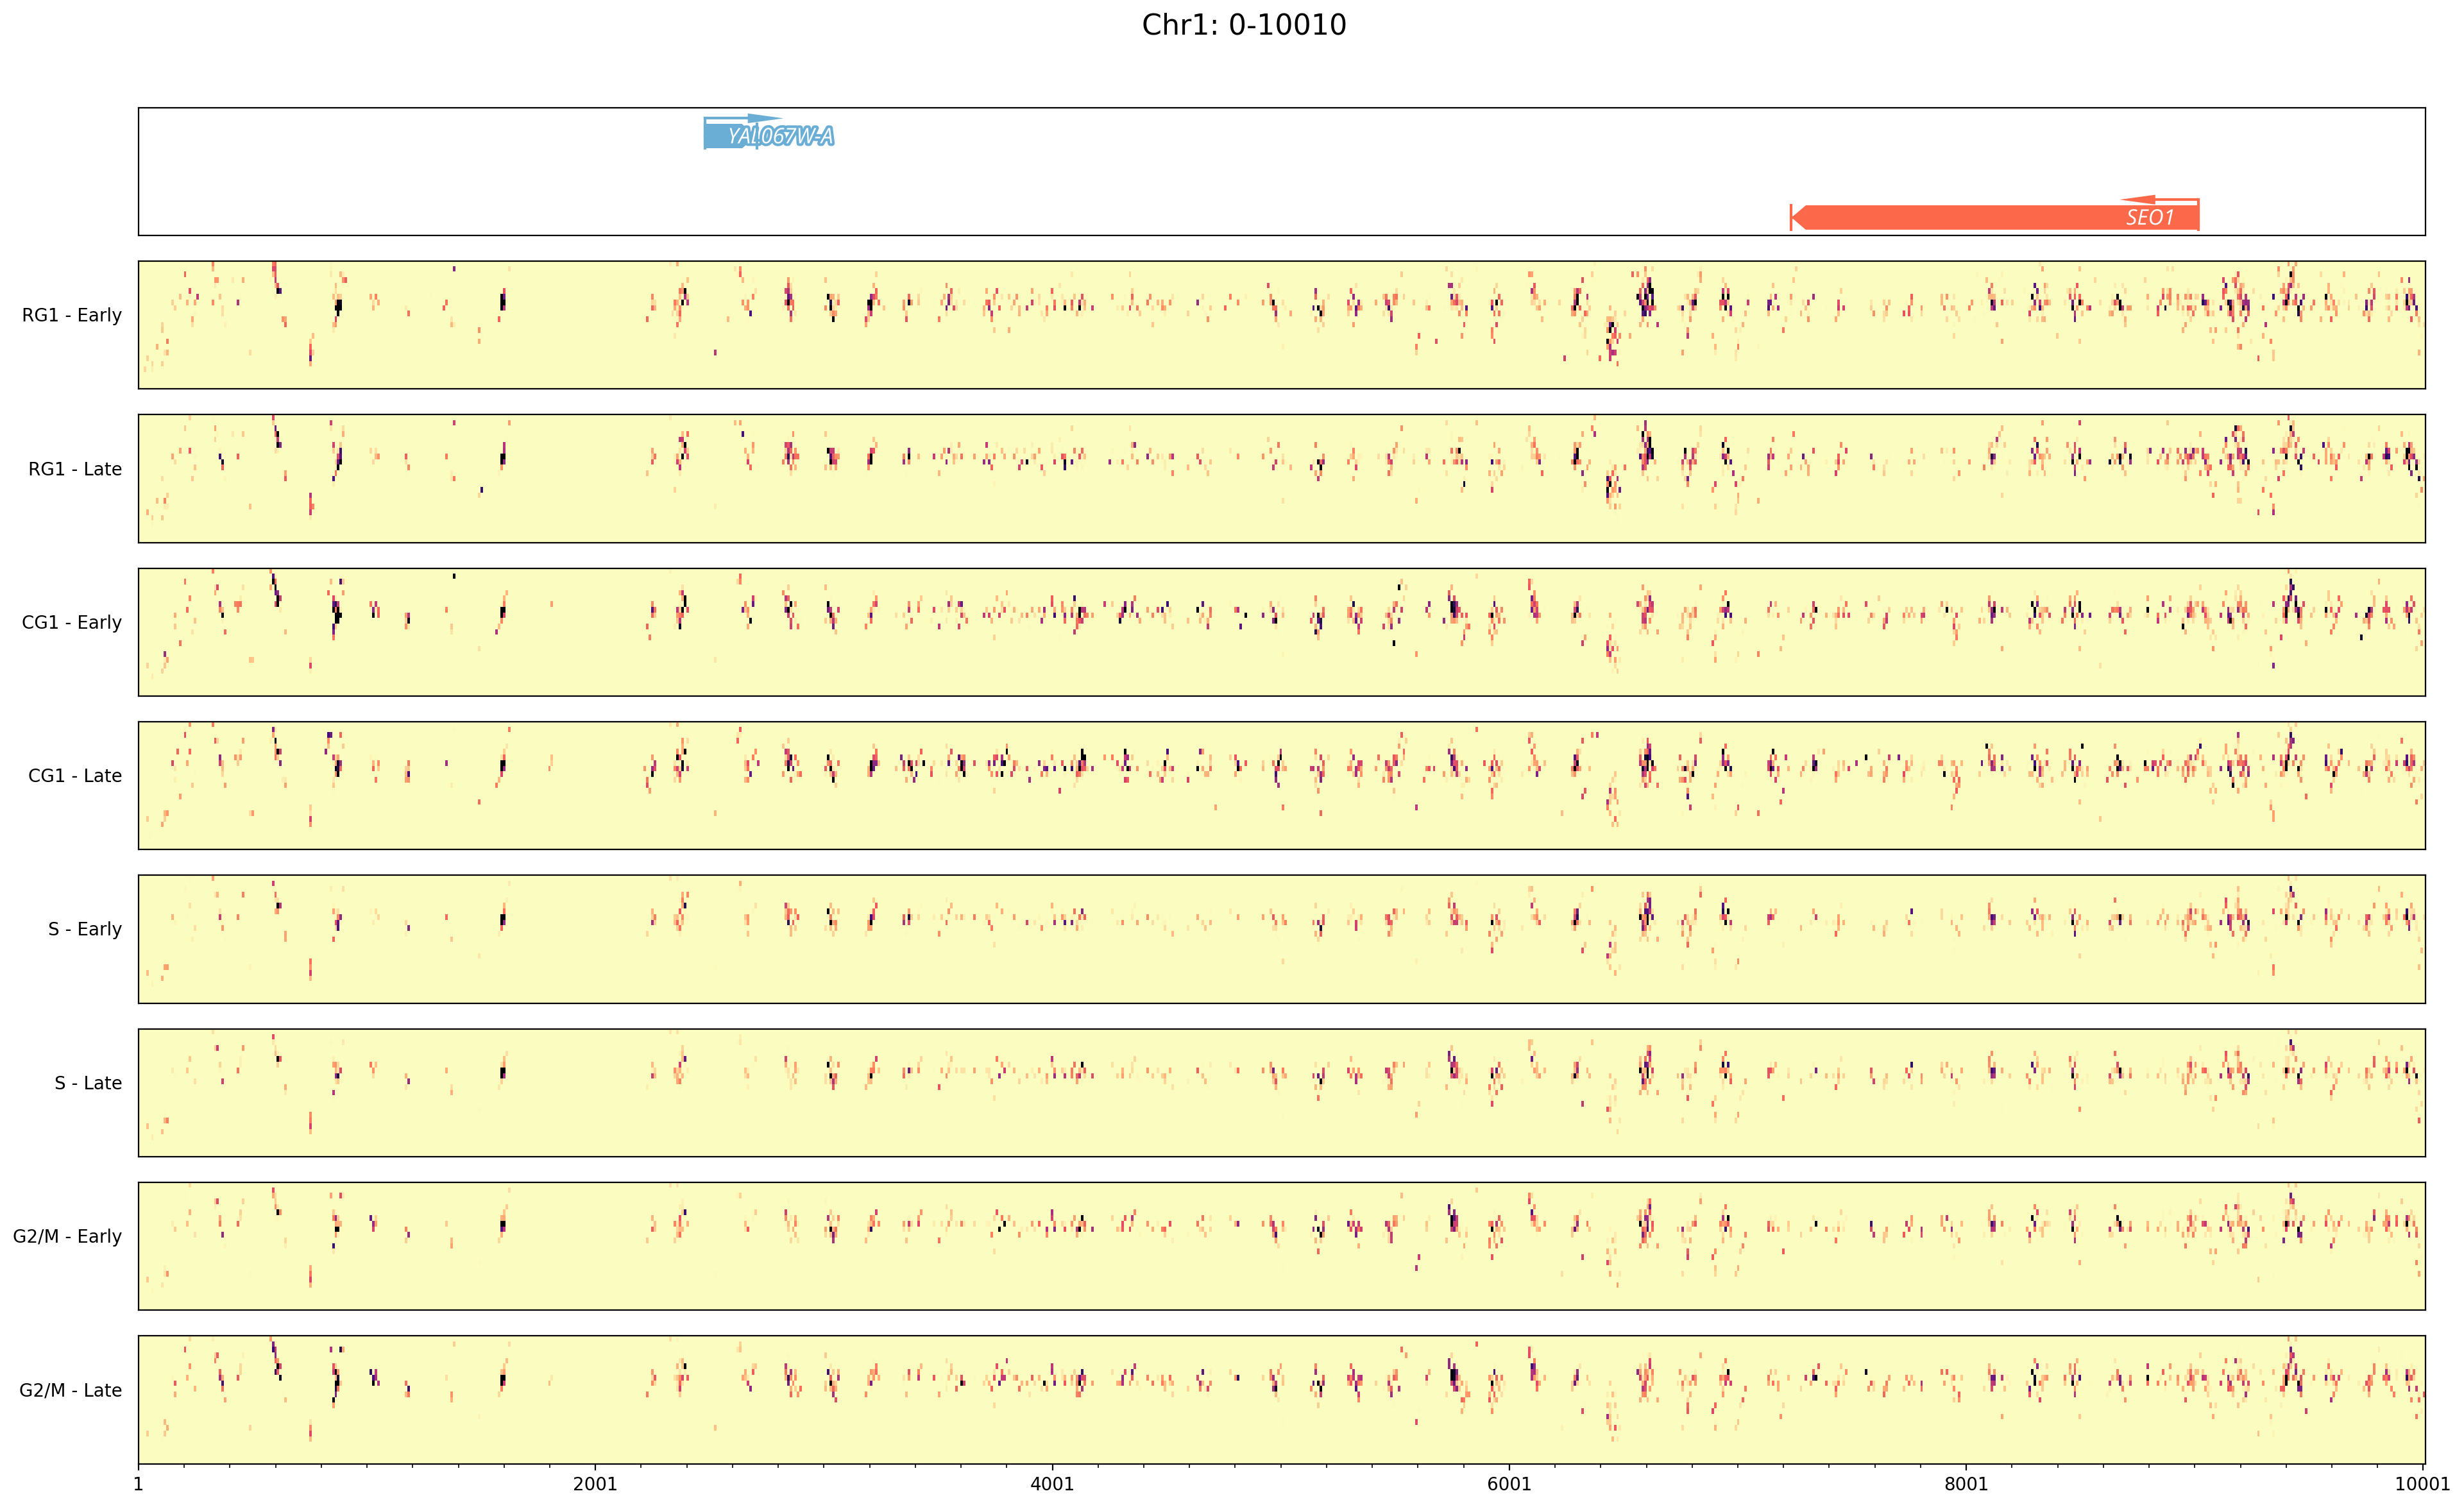

In [94]:
genome_deconvolution.plot_deconvolved_result(smooth=False)

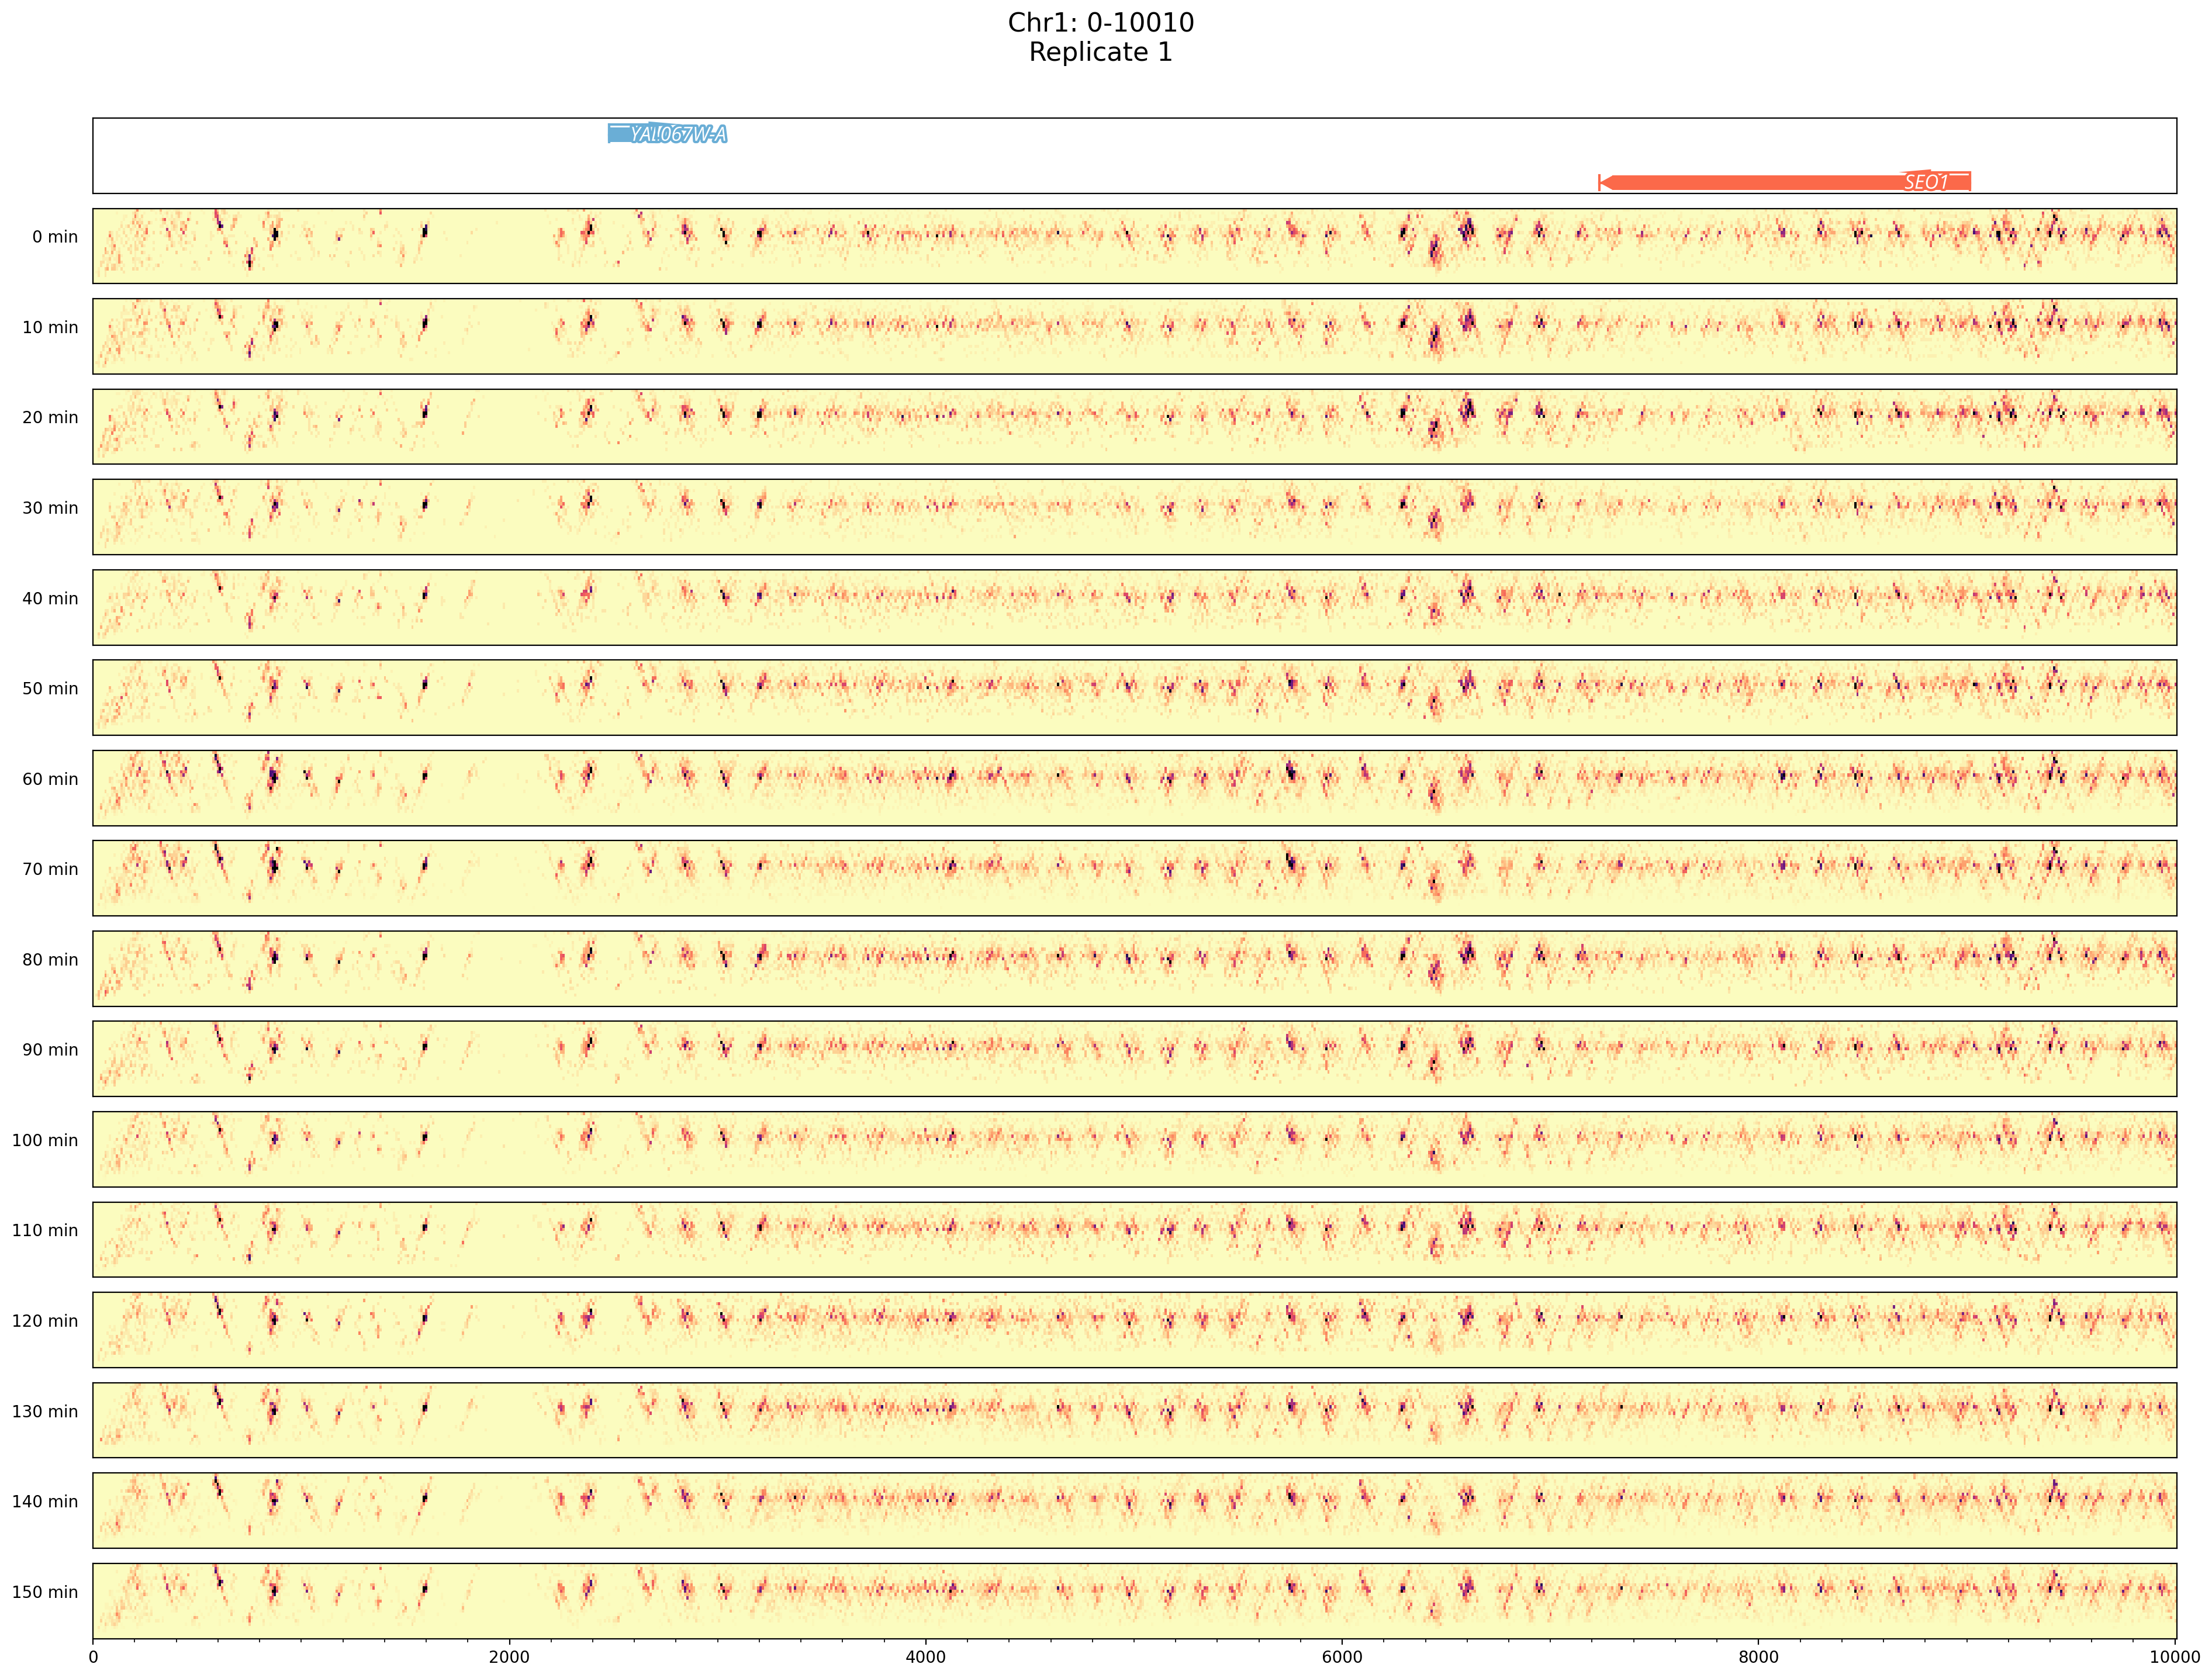

In [96]:
genome_deconvolution.plot_raw_data(1)

In [169]:
from src.GenomeDeconvolution import write_10k_windows_dataset_to_disk

# Write the list of 10k windows to deconvolve to disk
write_10k_windows_dataset_to_disk()

Wrote data/reference_data/sacCer3_genome_10k_windows.csv to disk.


In [161]:
from src.utils import mkdirs_safe

index = 10

genome_10K_windows = pd.read_csv('data/reference_data/sacCer3_genome_10k_windows.csv')
current_genomic_span = genome_10K_windows.loc[index]
chrom, span = current_genomic_span.chr, (current_genomic_span.start, current_genomic_span.end)

print(f"Deconvolving chr{chrom}, {span[0]}-{span[1]}")


Deconvolving chr1, 100000-110000
Creating directory: output/deconvolved_genome_g0066_10k_10x10_2024_09_19/plots/raw/replicate1/chr1...
Creating directory: output/deconvolved_genome_g0066_10k_10x10_2024_09_19/plots/raw/replicate2/chr1...
Creating directory: output/deconvolved_genome_g0066_10k_10x10_2024_09_19/plots/deconvolved/chr1...Directory exists. Skipping.
Creating directory: output/deconvolved_genome_g0066_10k_10x10_2024_09_19/data/chr1...Directory exists. Skipping.


In [ ]:
genome_deconvolution.save_to_disk()

In [176]:
genome_10K_windows

,chr,start,end
0,1,0,10000
1,1,10000,20000
2,1,20000,30000
3,1,30000,40000
4,1,40000,50000
...,...,...,...
1211,16,900000,910000
1212,16,910000,920000
1213,16,920000,930000
1214,16,930000,940000
